In [11]:
import pandas as pd
import matplotlib.pyplot as plt

caminho = "../data/tratados/sessoes_condominio.csv"
sessoes = pd.read_csv(caminho)

print(sessoes.shape)
sessoes.head()

(242, 16)


,session_id,user_id,user_name,unit,vehicle_model,battery_capacity_kwh,start_time,end_time,duration_minutes,energy_delivered_kwh,power_peak_kw,voltage_v,current_a,cost_rate_per_kwh,total_cost_brl,status
0,GW-202509172005,USR-004,Bruno Silva,Apto 102,BYD Seal,82.5,2025-09-17 20:05,2025-09-17 21:45,100,4.90,3.5,220.0,16.0,0.95,4.66,completed
1,GW-202509172145,USR-001,Aelton Menezes,Apto 42B,BYD Seal,82.5,2025-09-17 21:45,2025-09-18 02:05,260,9.70,3.5,220.0,16.0,0.95,9.21,completed
2,GW-202509182059,USR-002,Michelly Lima,Apto 15A,Volvo EX30,69.0,2025-09-18 20:59,2025-09-19 00:42,223,7.99,3.5,220.0,16.0,0.95,7.59,completed
3,GW-202509192147,USR-002,Michelly Lima,Apto 15A,Volvo EX30,69.0,2025-09-19 21:47,2025-09-20 01:27,220,7.79,3.5,220.0,16.0,0.95,7.40,completed
4,GW-202509211532,USR-004,Bruno Silva,Apto 102,BYD Seal,82.5,2025-09-21 15:32,2025-09-21 19:21,229,8.44,3.5,220.0,16.0,0.95,8.02,completed


In [12]:
sessoes.info()

<class 'pandas.DataFrame'>
RangeIndex: 242 entries, 0 to 241
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   session_id            242 non-null    str    
 1   user_id               242 non-null    str    
 2   user_name             242 non-null    str    
 3   unit                  242 non-null    str    
 4   vehicle_model         242 non-null    str    
 5   battery_capacity_kwh  242 non-null    float64
 6   start_time            242 non-null    str    
 7   end_time              242 non-null    str    
 8   duration_minutes      242 non-null    int64  
 9   energy_delivered_kwh  242 non-null    float64
 10  power_peak_kw         242 non-null    float64
 11  voltage_v             242 non-null    float64
 12  current_a             242 non-null    float64
 13  cost_rate_per_kwh     242 non-null    float64
 14  total_cost_brl        242 non-null    float64
 15  status                242 non-null

In [13]:
sessoes["inicio"] = pd.to_datetime(sessoes["start_time"])

sessoes["hora"] = sessoes["inicio"].dt.hour
sessoes["dia_semana"] = sessoes["inicio"].dt.dayofweek
sessoes["ano_mes"] = sessoes["inicio"].dt.to_period("M").astype(str)

nomes_dias = {0: "seg", 1: "ter", 2: "qua", 3: "qui", 4: "sex", 5: "sáb", 6: "dom"}
sessoes["nome_dia"] = sessoes["dia_semana"].map(nomes_dias)

sessoes[["start_time", "inicio", "hora", "dia_semana", "nome_dia", "ano_mes"]].head()

,start_time,inicio,hora,dia_semana,nome_dia,ano_mes
0,2025-09-17 20:05,2025-09-17 20:05:00,20,2,qua,2025-09
1,2025-09-17 21:45,2025-09-17 21:45:00,21,2,qua,2025-09
2,2025-09-18 20:59,2025-09-18 20:59:00,20,3,qui,2025-09
3,2025-09-19 21:47,2025-09-19 21:47:00,21,4,sex,2025-09
4,2025-09-21 15:32,2025-09-21 15:32:00,15,6,dom,2025-09


In [14]:
print(sessoes["inicio"].dtype)
print(sessoes["inicio"].min(), "até", sessoes["inicio"].max())
print("Início entre 17h e 23h:", round(sessoes["hora"].between(17, 23).mean(), 3))

datetime64[us]
2025-09-17 20:05:00 até 2026-09-29 21:02:00
Início entre 17h e 23h: 0.88


      sessoes  kwh_total
hora                    
0           1      10.43
1           1      12.50
2           1       8.25
3           0       0.00
4           0       0.00
5           0       0.00
6           0       0.00
7           0       0.00
8           3       7.04
9           2      13.34
10          3      16.32
11          0       0.00
12          5      27.56
13          4      28.50
14          1       1.01
15          3      24.43
16          5      43.22
17         16     164.27
18         13     125.07
19         21     175.18
20         59     440.99
21         80     629.00
22         18     113.70
23          6      42.31


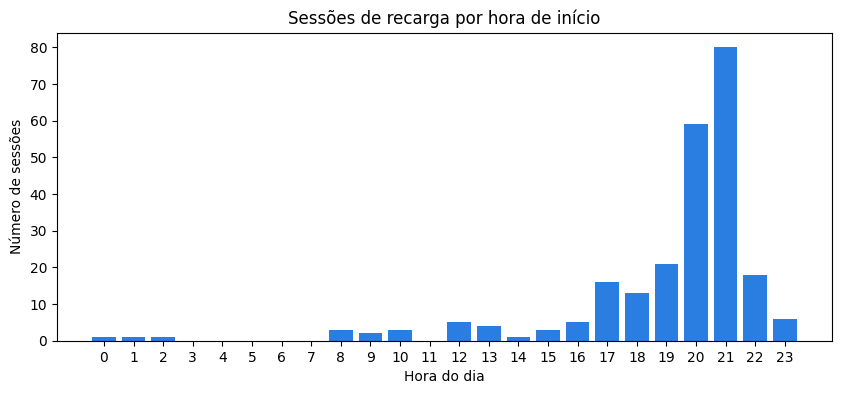

In [15]:
por_hora = sessoes.groupby("hora").agg(
    sessoes=("session_id", "count"),
    kwh_total=("energy_delivered_kwh", "sum")
).reindex(range(24), fill_value=0)

print(por_hora)

fig, eixo = plt.subplots(figsize=(10, 4))
eixo.bar(por_hora.index, por_hora["sessoes"], color="#2a7de1")
eixo.set_title("Sessões de recarga por hora de início")
eixo.set_xlabel("Hora do dia")
eixo.set_ylabel("Número de sessões")
eixo.set_xticks(range(24))
plt.show()

In [16]:
por_hora["kwh_total"] = por_hora["kwh_total"].round(1)
por_hora["pct_sessoes"] = (por_hora["sessoes"] / por_hora["sessoes"].sum() * 100).round(1)
por_hora["pct_kwh"] = (por_hora["kwh_total"] / por_hora["kwh_total"].sum() * 100).round(1)
por_hora

,sessoes,kwh_total,pct_sessoes,pct_kwh
hora,,,,
0,1,10.4,0.4,0.6
1,1,12.5,0.4,0.7
2,1,8.2,0.4,0.4
3,0,0.0,0.0,0.0
4,0,0.0,0.0,0.0
5,0,0.0,0.0,0.0
6,0,0.0,0.0,0.0
7,0,0.0,0.0,0.0
8,3,7.0,1.2,0.4


seg    5.25
ter    4.94
qua    6.22
qui    5.57
sex    4.15
sáb    1.91
dom    6.82
Name: energy_delivered_kwh, dtype: float64


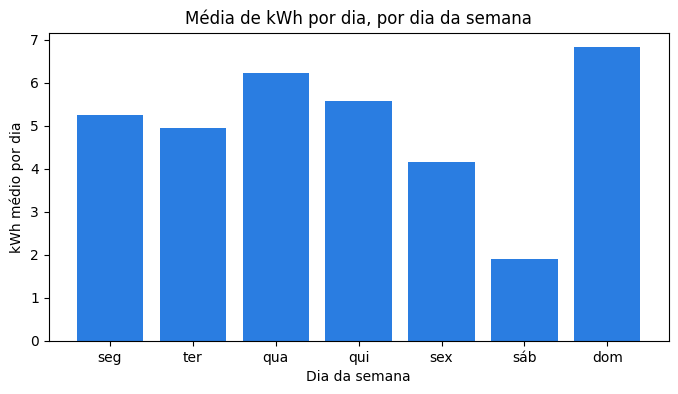

In [17]:
kwh_por_data = sessoes.groupby(sessoes["inicio"].dt.normalize())["energy_delivered_kwh"].sum()
calendario = pd.date_range(kwh_por_data.index.min(), kwh_por_data.index.max(), freq="D")
kwh_diario = kwh_por_data.reindex(calendario, fill_value=0)

media_por_dia = kwh_diario.groupby(kwh_diario.index.dayofweek).mean().round(2)
media_por_dia.index = media_por_dia.index.map(nomes_dias)
print(media_por_dia)

fig, eixo = plt.subplots(figsize=(8, 4))
eixo.bar(media_por_dia.index, media_por_dia.values, color="#2a7de1")
eixo.set_title("Média de kWh por dia, por dia da semana")
eixo.set_xlabel("Dia da semana")
eixo.set_ylabel("kWh médio por dia")
plt.show()

In [18]:
estatisticas = kwh_diario.groupby(kwh_diario.index.dayofweek).agg(["count", "mean", "median", "std"]).round(2)
estatisticas["pct_dias_sem_recarga"] = (kwh_diario.eq(0).groupby(kwh_diario.index.dayofweek).mean() * 100).round(0)
estatisticas.index = estatisticas.index.map(nomes_dias)
estatisticas

,count,mean,median,std,pct_dias_sem_recarga
seg,54,5.25,5.24,4.15,30.0
ter,54,4.94,5.48,4.42,37.0
qua,54,6.22,5.76,4.98,30.0
qui,54,5.57,6.04,4.70,33.0
sex,54,4.15,4.61,4.37,41.0
sáb,54,1.91,0.00,3.93,74.0
dom,54,6.82,6.72,5.71,31.0


         dias  kwh_total  kwh_medio_dia  sessoes
2025-09    14     105.65           7.55       17
2025-10    31     175.85           5.67       26
2025-11    30     172.59           5.75       22
2025-12    31     141.61           4.57       16
2026-01    31      85.33           2.75       10
2026-02    28     111.04           3.97       15
2026-03    31     177.78           5.73       25
2026-04    30     153.52           5.12       20
2026-05    31     166.78           5.38       20
2026-06    30     137.76           4.59       18
2026-07    31     167.77           5.41       17
2026-08    31     130.68           4.22       16
2026-09    29     156.76           5.41       20


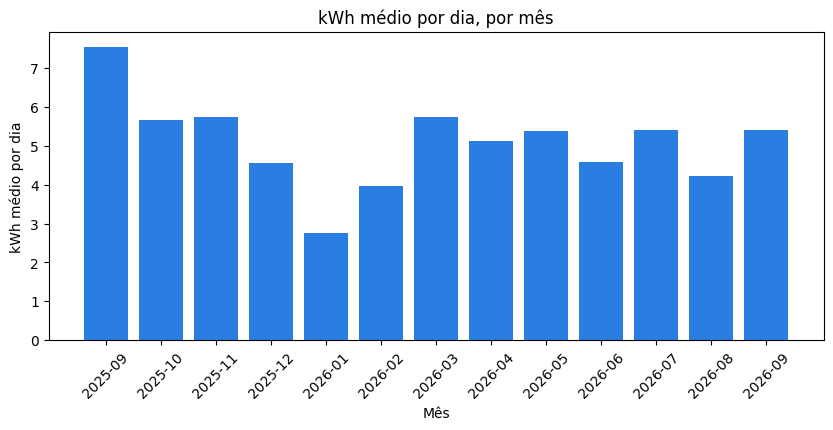

In [19]:
por_mes = kwh_diario.groupby(kwh_diario.index.to_period("M")).agg(
    dias="count", kwh_total="sum", kwh_medio_dia="mean"
).round(2)
por_mes.index = por_mes.index.astype(str)
por_mes["sessoes"] = sessoes.groupby("ano_mes").size()
print(por_mes)

fig, eixo = plt.subplots(figsize=(10, 4))
eixo.bar(por_mes.index, por_mes["kwh_medio_dia"], color="#2a7de1")
eixo.set_title("kWh médio por dia, por mês")
eixo.set_xlabel("Mês")
eixo.set_ylabel("kWh médio por dia")
eixo.tick_params(axis="x", rotation=45)
plt.show()

## Conclusões da análise temporal

Base: 242 sessões reais do carregador  GoodWe (Sems+) (17/09/2025 a 29/09/2026), de um único carro e um único cartão RFID. Usuários e veículos do condomínio são simulados sobre esse padrão.

1. **Hora:** 88% das sessões começam entre 17h e 23h, e as 20h e 21h concentram 57% das sessões e 57% da energia. É o pico a ser tratado na previsão, na recomendação operacional e na precificação.
2. **Dia da semana:** só o sábado se destaca (mediana de 0 kWh, 74% dos sábados sem recarga). Os demais dias são parecidos entre si; domingo tem a maior média, mas a diferença é menor que a variação normal dos dias.
3. **Mês:** de março a setembro/2026 a demanda é estável (cerca de 5,1 kWh por dia). Dezembro a fevereiro foram mais baixos, mas há uma única observação de cada mês, então não é possível afirmar sazonalidade.
4. **Demanda intermitente:** 30% a 41% dos dias úteis não têm recarga e o desvio padrão é do tamanho da média. Prever o kWh de um dia específico terá erro alto, e a confiança do modelo será calculada pela validação, não fixada.

**Decisões para o modelo:** usar hora e dia da semana (com atenção ao sábado) e o nível recente de uso; não usar o mês como variável; comparar qualquer modelo com a linha de base por dia da semana.

**Limitação:** o padrão é de uma única pessoa. Ele mostra uma rotina real, mas não prova o comportamento de um condomínio inteiro.